In [6]:
import emodeconnection as emc
import numpy as np
import matplotlib.pyplot as plt
import time


# Fixed parameters of Geometry
wavelength_fund = 450.0
w_core = 400.0  # [nm] Fixed width
h_core = 335.0  # [nm] Fixed height
dx, dy = 10.0, 10.0
doplots = False

# Sellmeier Material Definition
# Use double asterisks for power, ensure no spaces in the inner math, and verify the negative B3/C3 values are handled cleanly.
eq_o = '(1+2.8032/(1-0.015287/x**2)+0.36335/(1-0.036095/x**2)-33508000/(1+367200000/x**2))**0.5'
eq_e = '(1+0.017061/(1-0.043855/x**2)+3.1976/(1-0.022642/x**2)-57269000/(1-74226000/x**2))**0.5'
anisotropic_equation = f"[{eq_o},{eq_e},{eq_o}]"

In [7]:
## --- Resilient test: fresh em session per width, narrowed overlap search ---
test_widths = [395, 400]
Nmodes_shg = 35
overlap_window = 5  # check only modes within +/- this many indices of the previous match

ref_width = 400
ref_mode_idx = 30
results = []

for w in test_widths:
    print(f"\n--- Testing width: {w} nm (relaunching fresh EMode session) ---")
    try:
        em = emc.EMode(simulation_name='mode_track_test', clear='all')
        em.add_material(name='custom_AlN', refractive_index_equation=anisotropic_equation, wavelength_unit='um')
        em.settings(window_width=2000, window_height=h_core+2000, boundary_condition='TM')
        em.shape(name='Substrate', material='Al2O3', height=1000)
        em.shape(name='TopClad', material='SiO2', height=800, shape_type='conformal')

        # Re-solve the reference width fresh (previous session's labeled profile no longer exists)
        em.shape(name='core', material='custom_AlN', height=h_core, mask=ref_width, etch_depth=h_core, sidewall_angle=5)
        em.settings(wavelength=wavelength_fund/2, num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
        em.FDM()
        em.label_profile(name='ref')

        # Solve the width being tested
        em.shape(name='core', material='custom_AlN', height=h_core, mask=w, etch_depth=h_core, sidewall_angle=5)
        em.settings(wavelength=wavelength_fund/2, num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
        em.FDM()
        em.label_profile(name='cur')

        candidates = list(range(max(0, ref_mode_idx - overlap_window), min(Nmodes_shg, ref_mode_idx + overlap_window + 1)))
        overlaps = {m: abs(em.overlap(label_a='ref', mode_a=ref_mode_idx, label_b='cur', mode_b=m)) for m in candidates}
        best_idx = max(overlaps, key=overlaps.get)
        best_overlap = overlaps[best_idx]
        print(f"  Checked modes {candidates}")
        print(f"  Best match: mode {best_idx}, overlap = {best_overlap:.4f}")
        if best_overlap < 0.8:
            print(f"  WARNING: low overlap ({best_overlap:.3f}) - true match may be outside the +/-{overlap_window} window.")

        results.append((w, best_idx, best_overlap))
        em.close(save=False)
        ref_width, ref_mode_idx = w, best_idx

    except Exception as e:
        print(f"  FAILED at width {w}: {repr(e)}")
        results.append((w, None, None))

print("\nWidth (nm) | Best Match Mode | Overlap")
for w, idx, ov in results:
    print(f"{w:<11}| {str(idx):<17}| {ov if ov is None else f'{ov:.4f}'}")



--- Testing width: 395 nm (relaunching fresh EMode session) ---
  Checked modes [25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  Best match: mode 29, overlap = 1.0000

--- Testing width: 400 nm (relaunching fresh EMode session) ---
  Checked modes [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  Best match: mode 30, overlap = 1.0000

Width (nm) | Best Match Mode | Overlap
395        | 29               | 1.0000
400        | 30               | 1.0000


In [2]:
# Launch EMode 
clear='all'
em = emc.EMode(simulation_name='example_AlN_waveguide_sweep1')

In [3]:
# Set Up Simulation
em.add_material(name='custom_AlN',                                  
                refractive_index_equation=anisotropic_equation, 
                wavelength_unit='um')
em.settings(window_width=2000,window_height=h_core+2000, boundary_condition='TM') # Using your 'TM' preference)
em.shape(name='Substrate', material='Al2O3', height=1000)
em.shape(name='core', material='custom_AlN', height=h_core, mask=w_core, etch_depth=h_core, sidewall_angle=5)
em.shape(name='TopClad', material='SiO2', height=800, shape_type='conformal')
if doplots: em.plot()


In [5]:
## --- Minimal test: does overlap-based tracking correctly find mode 30 at widths 395/400,
##     when run as a loop in this same session (not an isolated fresh check)? ---
test_widths = [395, 400]
Nmodes_shg = 35

ref_label = 'test_ref_400'
em.shape(name='core', material='custom_AlN', height=h_core, mask=400, etch_depth=h_core, sidewall_angle=5)
em.settings(wavelength=wavelength_fund/2, num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()
em.label_profile(name=ref_label)
ref_mode_idx = 30

for w in test_widths:
    print(f"\n--- Testing width: {w} nm ---")
    em.shape(name='core', material='custom_AlN', height=h_core, mask=w, etch_depth=h_core, sidewall_angle=5)
    em.settings(wavelength=wavelength_fund/2, num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
    em.FDM()
    new_label = f'test_w{w}'
    em.label_profile(name=new_label)

    overlaps = [abs(em.overlap(label_a=ref_label, mode_a=ref_mode_idx, label_b=new_label, mode_b=m))
                for m in range(Nmodes_shg)]
    best_idx = int(np.argmax(overlaps))
    print(f"  Best match: mode {best_idx}, overlap = {overlaps[best_idx]:.4f}  (mode 30 specifically: {overlaps[30]:.4f})")

    ref_label, ref_mode_idx = new_label, best_idx



--- Testing width: 395 nm ---
  Best match: mode 30, overlap = 0.9998  (mode 30 specifically: 0.9998)

--- Testing width: 400 nm ---


ConnectionError: connection interrupted? expected 4 bytes, but only got 0

In [6]:
# Calculate Modes for FUNDAMENTAL WAVELENGTH
Nmodes_to_calculate = 2
em.settings(wavelength=wavelength_fund, x_resolution=dx, y_resolution=dy,window_width=2000,
            window_height=h_core+2000, num_modes=Nmodes_to_calculate, boundary_condition='TM') # Using your 'TM' preference)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset1') #store this set of results under label '0'
if doplots: em.plot()


In [11]:
## Run wavelength sweep:  FUNDAMENTAL WAVELENGTH
wav_nm = np.arange(448, 462, 2)

data = em.sweep(key = 'wavelength', values = wav_nm,
    result = ['effective_index'])  # 'mode_order' removed: crashes EMode backend on this sweep and isn't used downstream
em.call("EM_save", simulation_name='example_AlN_waveguide_sweep1.eph')  # em.save() is shadowed by the em.save bool attribute set in __init__; call() bypasses that

'ok'

In [12]:
# Calculate Modes for SECOND HARMONIC WAVELENGTH
Nmodes_to_calculate = 35
em.settings(num_modes=Nmodes_to_calculate, wavelength=wavelength_fund/2, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()                            #run the finite difference mode solver to find the modes of the structure
em.confinement(shape_list='core')   #calculate the confinement factor for each mode
em.report()                         #print information about the calculation results to command line
em.label_profile(name = 'dataset2') #store this set of results under label 'dataset2'
if doplots: em.plot()


In [13]:
## Run wavelength sweep:  SECOND HARMONIC WAVELENGTH
wav2_nm = wav_nm/2
data2 = em.sweep(key = 'wavelength',                        #which parameter to sweep
                 values = wav2_nm,                          #values to sweep over
                 result = ['effective_index']) #which results to return for each sweep step; 'mode_order' removed, see fundamental sweep cell above
em.call("EM_save", simulation_name='example_AlN_waveguide_sweep1.eph')  # em.save() is shadowed by the em.save bool attribute set in __init__; call() bypasses that


'ok'

Success! Phase Match at SHG WL: 225.525 nm

--- Phase Matching Results ---
Target SHG Mode Index: 30
SHG Phase Match WL:    225.525 nm
Fundamental Match WL:  451.049 nm
d(n_eff)/d(WL) at crossing - Fundamental mode: -1.603954e-03 per nm
d(n_eff)/d(WL) at crossing - SHG mode 30:      -1.547512e-02 per nm


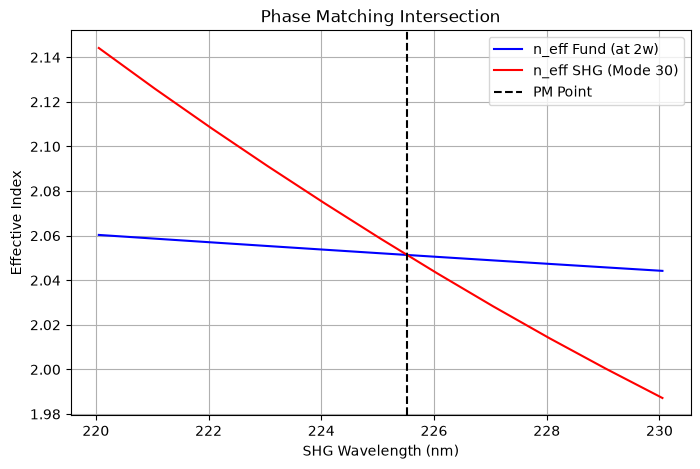

In [17]:
## --- Phase Matching Analysis ---
# 1. Extract Neff from Fundamental Sweep (Mode 0 = TM00/TE00)
neff_fund = np.array(data['effective_index'])[:, 0]

# 2. Extract Neff from SHG Sweep (Target Mode)
# Let's assume TM04 is index 30 for now; we can refine this later
target_sh_idx = 30 
neff_shg = np.array(data2['effective_index'])[:, target_sh_idx]

# 3. Calculate Delta N (We want this to be 0)
# Note: We use wav2_nm as the x-axis because it represents the SHG wavelength
delta_n = neff_fund - neff_shg

# 4. Use linear interpolation to find the exact zero-crossing
# np.interp requires the x-coordinates to be increasing. 
# Since n_eff drops with wavelength, delta_n is usually monotonic.

# Check if a crossing exists (sign change)
if np.sign(delta_n[0]) != np.sign(delta_n[-1]):
    # Note: wav2_nm must be increasing for np.interp
    pm_wl_shg = np.interp(0, delta_n, wav2_nm)
    print(f"Success! Phase Match at SHG WL: {pm_wl_shg:.3f} nm")

    # Slope of each dispersion curve (n_eff vs wavelength) right at the crossing point.
    # np.gradient gives the local slope at every sampled wavelength; interpolate that
    # slope curve to the exact (non-sampled) crossing wavelength found above.
    slope_fund = np.interp(pm_wl_shg, wav2_nm, np.gradient(neff_fund, wav2_nm))
    slope_shg = np.interp(pm_wl_shg, wav2_nm, np.gradient(neff_shg, wav2_nm))
else:
    # If no crossing, tell us which direction to move the window
    direction = "increase" if delta_n[0] > 0 else "decrease"
    print(f"No crossing found. Try to {direction} your wavelength range.")
    pm_wl_shg = [];
    slope_fund = slope_shg = np.nan


print(f"\n--- Phase Matching Results ---")
print(f"Target SHG Mode Index: {target_sh_idx}")
print(f"SHG Phase Match WL:    {pm_wl_shg:.3f} nm")
print(f"Fundamental Match WL:  {pm_wl_shg * 2:.3f} nm")
print(f"d(n_eff)/d(WL) at crossing - Fundamental mode: {slope_fund:.6e} per nm")
print(f"d(n_eff)/d(WL) at crossing - SHG mode {target_sh_idx}:      {slope_shg:.6e} per nm")

# 5. Quick Plot to verify the crossing
plt.figure(figsize=(8, 5))
plt.plot(wav2_nm, neff_fund, 'b-', label='n_eff Fund (at 2w)')
plt.plot(wav2_nm, neff_shg, 'r-', label=f'n_eff SHG (Mode {target_sh_idx})')
plt.axvline(pm_wl_shg, color='k', linestyle='--', label='PM Point')
plt.xlabel('SHG Wavelength (nm)')
plt.ylabel('Effective Index')
plt.title('Phase Matching Intersection')
plt.legend()
plt.grid(True)
plt.show()


--- Processing Width: 395.0 nm ---
  Tracked SHG mode: index 31 (overlap with previous width's mode = 0.7355)


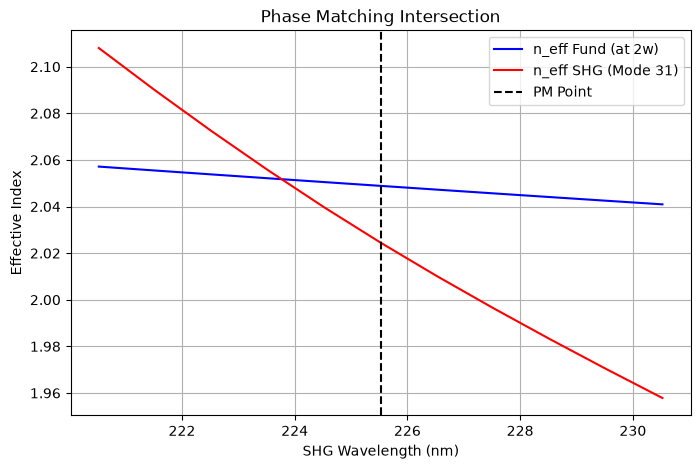

Found PM at 223.769 nm

--- Processing Width: 400.0 nm ---
  Tracked SHG mode: index 31 (overlap with previous width's mode = 0.7391)


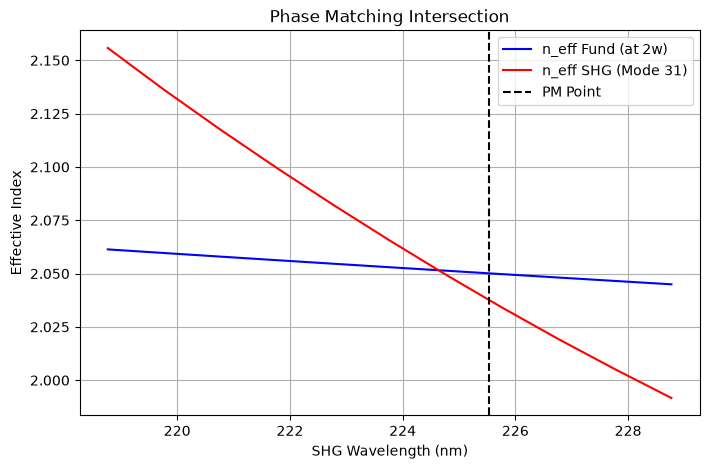

Found PM at 224.638 nm

--- Processing Width: 405.0 nm ---
  Tracked SHG mode: index 30 (overlap with previous width's mode = 0.9943)


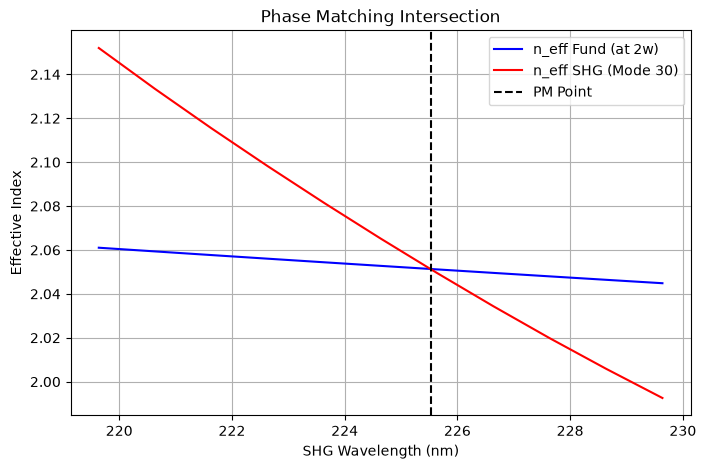

Found PM at 225.522 nm


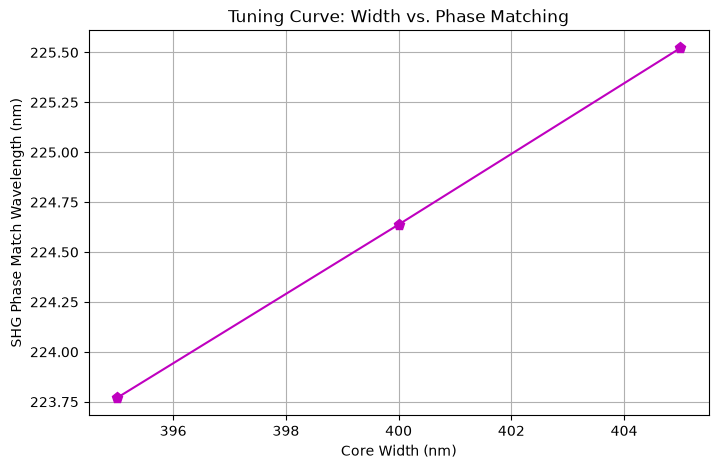


Width (nm) | Tracked Mode Index | Overlap with previous width
395        | 31                  | 0.7355
400        | 31                  | 0.7391
405        | 30                  | 0.9943


In [18]:
## --- 2D Design Loop: Width Sweep (with mode tracking across widths) ---
widths = np.arange(w_core-5, w_core+6, 5)# Sweep width from 340nm to 460nm
pm_results = []
tracked_mode_indices = []  # which mode index turned out to be "the" SHG mode at each width
tracked_overlaps = []      # overlap with the previous width's mode, for sanity-checking the track
Nmodes_shg = 35

# Define a narrow sweep range (e.g., +/- 5nm around a center)
# You can update this 'center' based on the previous result to track the PM point
current_pm_center = pm_wl_shg

# --- Establish the initial reference SHG mode at the starting (current) width/geometry ---
# This reuses the mode index (target_sh_idx) you already confirmed above via the crossing analysis.
ref_label = 'shg_ref_init'
em.settings(wavelength=current_pm_center, num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()
em.label_profile(name=ref_label)
ref_mode_idx = target_sh_idx

for w in widths:
    print(f"\n--- Processing Width: {w} nm ---")
    
    # 1. Update Geometry
    em.shape(name='core', material='custom_AlN', height=h_core, mask=w, 
             etch_depth=h_core, sidewall_angle=5)
    
    # 2. Define narrow wavelength windows for speed
    wav2_nm = np.linspace(current_pm_center - 5, current_pm_center + 5, 11)
    wav_fund = wav2_nm * 2

    # 3. Re-identify the SHG mode at this width by spatial-overlap comparison to the
    #    previous width's mode, instead of assuming the mode index stays fixed. Mode
    #    ordering (by effective index) can reorder as geometry changes, so a fixed
    #    index like 30 may silently point at a different physical mode from width to width.
    em.settings(wavelength=wav2_nm[len(wav2_nm) // 2], num_modes=Nmodes_shg,
                x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
    em.FDM()
    new_label = f'shg_w{w:.0f}'
    em.label_profile(name=new_label)

    overlaps = [abs(em.overlap(label_a=ref_label, mode_a=ref_mode_idx, label_b=new_label, mode_b=m))
                for m in range(Nmodes_shg)]
    target_sh_idx = int(np.argmax(overlaps))
    best_overlap = overlaps[target_sh_idx]
    tracked_mode_indices.append(target_sh_idx)
    tracked_overlaps.append(best_overlap)
    print(f"  Tracked SHG mode: index {target_sh_idx} (overlap with previous width's mode = {best_overlap:.4f})")
    if best_overlap < 0.8:
        print(f"  WARNING: low overlap ({best_overlap:.3f}) - mode may have mixed/crossed at this width; verify by plotting.")

    # Walk the reference forward: this width's identified mode becomes the reference for the next width
    ref_label, ref_mode_idx = new_label, target_sh_idx

    # 4. Run Fundamental Sweep
    em.settings(wavelength=wav_fund[0], num_modes=2,  x_resolution=dx, y_resolution=dy)
    data = em.sweep(key='wavelength', values=wav_fund, result=['effective_index'])
    neff_fund = np.array(data['effective_index'])[:, 0]
    
    # 5. Run SHG Sweep (using the tracked mode index for this width)
    em.settings(wavelength=wav2_nm[0], num_modes=Nmodes_shg, x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
    data2 = em.sweep(key='wavelength', values=wav2_nm, result=['effective_index'])
    neff_shg = np.array(data2['effective_index'])[:, target_sh_idx]
    
    # 6.
    plt.figure(figsize=(8, 5))
    plt.plot(wav2_nm, neff_fund, 'b-', label='n_eff Fund (at 2w)')
    plt.plot(wav2_nm, neff_shg, 'r-', label=f'n_eff SHG (Mode {target_sh_idx})')
    plt.axvline(pm_wl_shg, color='k', linestyle='--', label='PM Point')
    plt.xlabel('SHG Wavelength (nm)')
    plt.ylabel('Effective Index')
    plt.title('Phase Matching Intersection')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 7. Find Intersection (Your combined logic)
    delta_n = neff_fund - neff_shg
    if np.sign(delta_n[0]) != np.sign(delta_n[-1]):
        res_wl = np.interp(0, delta_n, wav2_nm)
        pm_results.append(res_wl)
        current_pm_center = res_wl  # Update center for next width iteration
        print(f"Found PM at {res_wl:.3f} nm")
    else:
        print("Warning: Phase match moved outside current wavelength window.")
        pm_results.append(np.nan)

## --- Final Plot of the Tuning Curve ---
plt.figure(figsize=(8, 5))
plt.plot(widths, pm_results, 'm-p', markersize=8, label='PM Wavelength')
plt.xlabel('Core Width (nm)')
plt.ylabel('SHG Phase Match Wavelength (nm)')
plt.title('Tuning Curve: Width vs. Phase Matching')
plt.grid(True)
plt.show()

## --- Sanity check: did the tracked mode index/overlap stay stable across widths? ---
print("\nWidth (nm) | Tracked Mode Index | Overlap with previous width")
for w, idx, ov in zip(widths, tracked_mode_indices, tracked_overlaps):
    print(f"{w:<11.0f}| {idx:<20}| {ov:.4f}")

In [21]:
em = emc.EMode(simulation_name='example_AlN_waveguide_sweep1')

# Quick visual check: are modes 30 and 31 truly distinct shapes at width=395nm,
# or just two very similar-looking near-degenerate modes?
em.shape(name='core', material='custom_AlN', height=h_core, mask=395,
         etch_depth=h_core, sidewall_angle=5)
em.settings(wavelength=current_pm_center, num_modes=Nmodes_shg,
            x_resolution=dx/2, y_resolution=dy/2, max_effective_index=2.6)
em.FDM()

em.plot(mode=30, component='Ex')  # opens the native "EMode Plot" window -- find/close it to continue, same as before
em.plot(mode=31, component='Ex')

# reset geometry back to your working width when done comparing
em.shape(name='core', material='custom_AlN', height=h_core, mask=w_core,
         etch_depth=h_core, sidewall_angle=5)



EModeError: 'custom_AlN'

In [14]:
widths = np.arange(w_core-5, w_core+6, 5)
print(widths)

[395. 400. 405.]


In [4]:
em.close()

NameError: name 'em' is not defined